# edgeR DE Analysis — 10X vs Parse (all human datasets)

Pseudobulk differential expression across 5 human analyses using `edgepython`.  
Each analysis contributes one 10X and one PolyT pseudobulk sample (10 samples total).  
Design: `~tissue + tech` — tissue type absorbs biological variation, `tech` coefficient tests 10X vs PolyT.  
Significance: FDR < 0.05 (BH). Positive logFC = higher in PolyT.

In [54]:
from pathlib import Path
from typing import Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import edgepython as ep
import gseapy as gp
from XvP_utils import plotting
import re

%matplotlib inline

project_dir = Path("/home/mcaskey/10XvParse/")

# (label, analysis_name, parse_assay, parse_assay, tissue)
SAMPLES = [
    ("A3_H1", "Analysis_3", "parse_H1",  "parse_H1",  "PBMC"),
    ("A3_H2", "Analysis_3", "parse_H2",  "parse_H2",  "PBMC"),
    ("A5",    "Analysis_5", "parse",      "parse",      "Frozen PBMC"),
    #("A6",    "Analysis_6", "parse",      "parse",      "Cancer"),
    ("A7",    "Analysis_7", "parse",      "parse",      "Frozen PBMC"),
]

# Output dirs expected by the shared plotting helpers
for d in ["randO_outliers", "polyT_outliers"]:
    Path(d).mkdir(exist_ok=True)

In [55]:
randO_series  = {}
polyT_series = {}

for label, analysis, tenx_assay, polyT_assay, tissue in SAMPLES:
    print(f"Loading {label}...")
    rd = plotting.init_processing(
        analysis_name=analysis, project_dir=project_dir,
        data_name="randO", assay=tenx_assay, data_title=f"{label} randO",
    )
    pd_ = plotting.init_processing(
        analysis_name=analysis, project_dir=project_dir,
        data_name="polyT", assay=polyT_assay, data_title=f"{label} polyT",
        modified=True,
    )
    randO_series[f"{label}_randO"]    = pd.Series(np.asarray(rd.X.sum(axis=0)).flatten(),  index=rd.var_names)
    polyT_series[f"{label}_polyT"] = pd.Series(np.asarray(pd_.X.sum(axis=0)).flatten(), index=pd_.var_names)

# Inner join: genes present in all 10 samples with at least 10 total counts across all samples
randO_df  = pd.DataFrame(randO_series)
polyT_df = pd.DataFrame(polyT_series)
combined = pd.concat([randO_df, polyT_df], axis=1).dropna()
combined = combined.loc[combined.sum(axis=1) > 0]
print(f"\n{len(combined)} genes retained across all 10 samples")

Loading A3_H1...
Loading A3_H2...
Loading A5...
Loading A7...

26817 genes retained across all 10 samples


TMM norm factors: [1.0386 1.0349 1.0702 0.9136 0.9758 1.0206 1.0614 0.9002]
Design: 8 samples x 3 coefficients  (df.residual = 5)
Retained 22690 / 26817 genes after filterByExpr


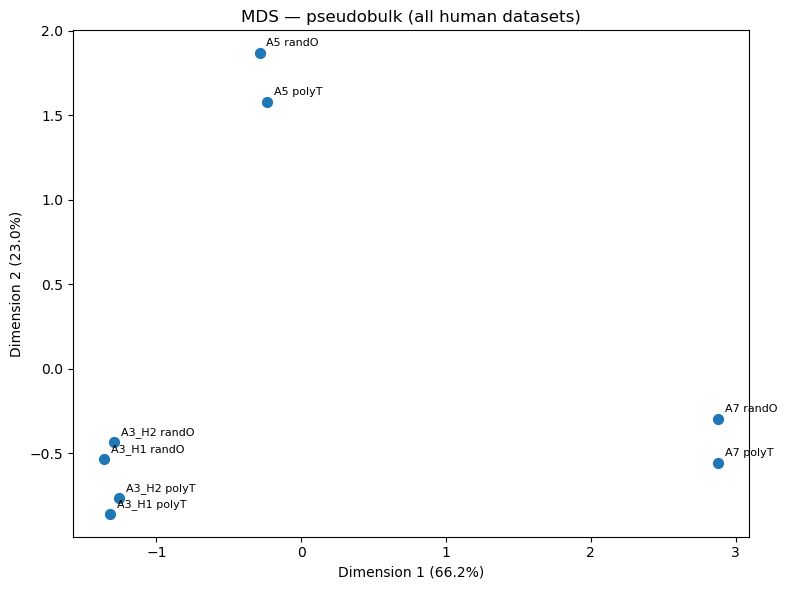

In [56]:
labels      = [s[0] for s in SAMPLES]
tissue_map  = {s[0]: s[4] for s in SAMPLES}
col_labels  = [f"{l} randO" for l in labels] + [f"{l} polyT" for l in labels]
tissues     = [tissue_map[l] for l in labels]  # 5 values, repeated for randO then polyT

counts_matrix = combined.values          # genes x 10
gene_names    = combined.index.tolist()
genes_df      = pd.DataFrame({"gene_name": gene_names})

# DGEList and TMM normalisation
dge = ep.make_dgelist(counts=counts_matrix, genes=genes_df)
dge = ep.calc_norm_factors(dge, method="TMM")
print("TMM norm factors:", np.round(dge["samples"]["norm.factors"].values, 4))

# Design matrix: ~tissue + tech  (Cancer = reference tissue, randO = reference tech)
design_data = pd.DataFrame({
    "tissue": pd.Categorical(tissues * 2, categories=["Frozen PBMC", "PBMC"]),
    "tech":   pd.Categorical(["randO"] * 4 + ["polyT"] * 4, categories=["randO", "polyT"]),
})
design = ep.model_matrix("~tissue+tech", data=design_data)
print(f"Design: {design.shape[0]} samples x {design.shape[1]} coefficients  "
      f"(df.residual = {design.shape[0] - design.shape[1]})")

# Filter low-count genes
keep  = ep.filter_by_expr(dge, design=design)
dge_f = dge.copy()
dge_f["counts"] = dge["counts"][keep]
dge_f["genes"]  = dge["genes"].iloc[keep]
print(f"Retained {keep.sum()} / {len(keep)} genes after filterByExpr")

# MDS plot
ep.plot_mds(dge_f, labels=col_labels, main="MDS — pseudobulk (all human datasets)")
plt.show()

Common dispersion (BCV): 0.4835


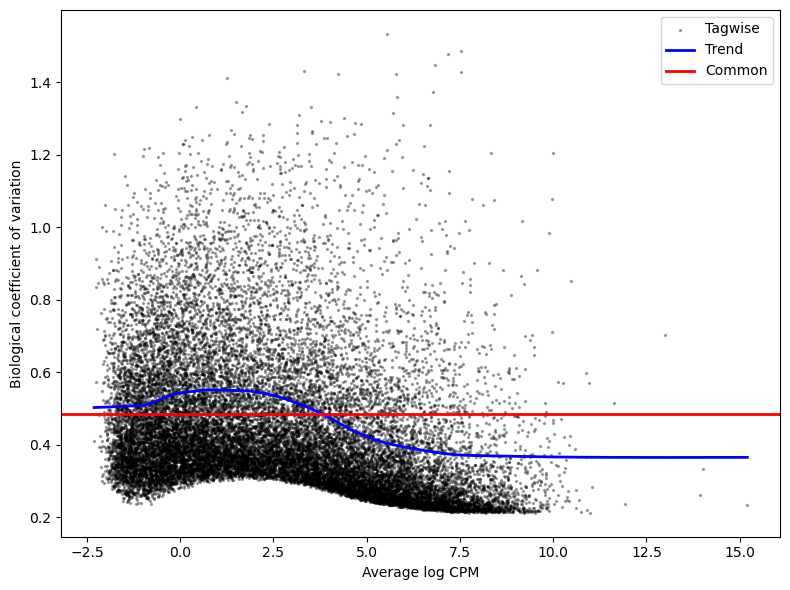

In [57]:
dge_f = ep.estimate_disp(dge_f, design=design)
print(f"Common dispersion (BCV): {np.sqrt(dge_f['common.dispersion']):.4f}")

ep.plot_bcv(dge_f, main="BCV plot")
plt.show()

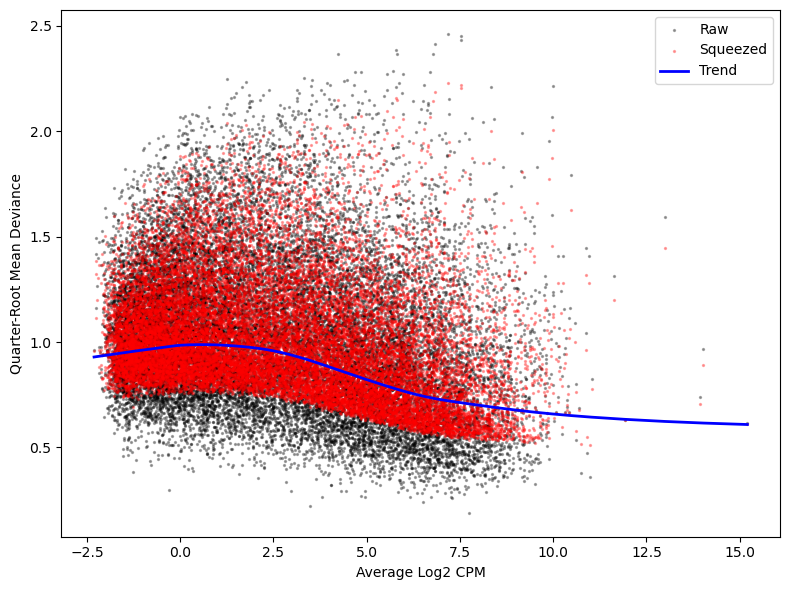

In [58]:
fit = ep.glm_ql_fit(dge_f, design=design)

ep.plot_ql_disp(fit, main="QL dispersion")
plt.show()

In [59]:
# Test the last design coefficient = techparse (polyT vs randO)
qlf = ep.glm_ql_ftest(fit, coef=design.shape[1] - 1)

tt      = ep.top_tags(qlf, n=keep.sum(), adjust_method="BH", sort_by="PValue")
results = tt["table"].copy()

# Merge gene annotations
attrs = pd.read_csv(
    project_dir / "Notebooks/Analysis_5/gene_data/gene_attributes.csv",
    usecols=["gene_name", "gene_length", "gc_content",
             "is_lnc", "is_pc", "is_mito", "is_ribo"],
)
results = results.merge(attrs, on="gene_name", how="left")

n_randO   = ((results["FDR"] < 0.05) & (results["logFC"] < 0)).sum()
n_polyT = ((results["FDR"] < 0.05) & (results["logFC"] > 0)).sum()
print(f"FDR < 0.05:  {n_randO} genes higher in randO,  {n_polyT} genes higher in polyT")

results.head(20)

FDR < 0.05:  2672 genes higher in randO,  1338 genes higher in polyT


,gene_name,logFC,logCPM,PValue,F,FDR,gene_length,gc_content,is_lnc,is_pc,is_mito,is_ribo
0,PLEC,-3.371272,7.942935,8.713276e-08,408.566205,0.000788,12795.294118,66.463328,False,True,False,False
1,SBF1,-3.225921,5.827100,1.690403e-07,340.981894,0.000788,3928.037500,64.274132,False,True,False,False
2,PPP1R9B,-3.112722,6.068238,1.692995e-07,340.838997,0.000788,2902.500000,63.801583,False,True,False,False
3,MYO1G,-2.463759,7.286430,1.871288e-07,331.628549,0.000788,3586.142857,60.603575,False,True,False,False
4,FLNA,-3.419588,9.209155,1.881553e-07,331.132596,0.000788,4842.967742,62.032198,False,True,False,False
5,RN7SL336P,4.206239,0.735160,2.257592e-07,192.879023,0.000788,297.000000,54.882155,False,False,False,False
6,TSC22D4,-4.535945,3.761760,2.431052e-07,309.355085,0.000788,1484.200000,65.021536,False,True,False,False
7,CORO1A,-2.311085,6.172484,5.283783e-07,249.451571,0.001499,1364.966667,63.120783,False,True,False,False
8,NOTCH1,-2.201829,6.490533,6.401124e-07,236.613045,0.001614,6782.647059,63.639392,False,True,False,False
9,CACTIN,-3.074043,3.697940,7.514521e-07,226.432972,0.001645,2170.272727,63.821201,False,True,False,False


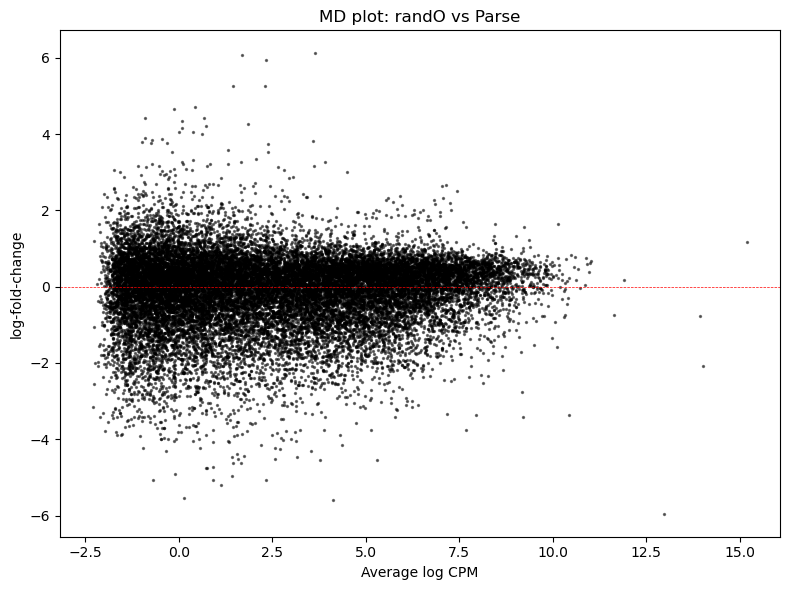

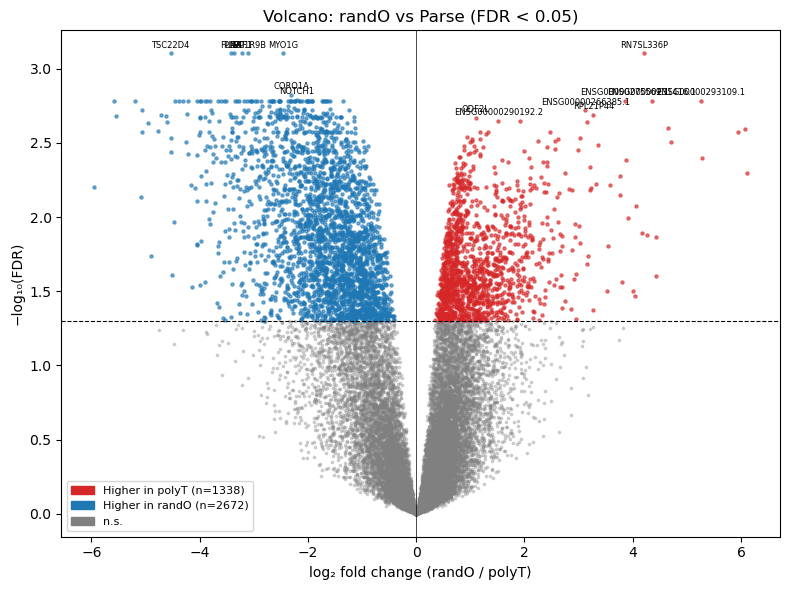

In [60]:
# MD plot
ep.plot_md(qlf, main="MD plot: randO vs Parse")
plt.show()

# Volcano
sig_polyT = (results["FDR"] < 0.05) & (results["logFC"] > 0)
sig_randO   = (results["FDR"] < 0.05) & (results["logFC"] < 0)
ns        = ~(sig_polyT | sig_randO)

nlp = -np.log10(results["FDR"].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(results.loc[ns,      "logFC"], nlp[ns],       c="grey",    s=3, alpha=0.3)
ax.scatter(results.loc[sig_randO, "logFC"], nlp[sig_randO],  c="#1f77b4", s=5, alpha=0.6)
ax.scatter(results.loc[sig_polyT,"logFC"],nlp[sig_polyT], c="#d62728", s=5, alpha=0.6)
ax.axhline(-np.log10(0.05), color="black", linewidth=0.8, linestyle="--", label="FDR = 0.05")
ax.axvline(0, color="black", linewidth=0.5)

for sub in [results[sig_randO].nsmallest(8, "FDR"),
            results[sig_polyT].nsmallest(8, "FDR")]:
    for _, row in sub.iterrows():
        ax.annotate(row["gene_name"],
                    (row["logFC"], -np.log10(row["FDR"])),
                    fontsize=6, ha="center",
                    xytext=(0, 4), textcoords="offset points")

ax.set_xlabel("log\u2082 fold change (randO / polyT)")
ax.set_ylabel("\u2212log\u2081\u2080(FDR)")
ax.set_title("Volcano: randO vs Parse (FDR < 0.05)")
ax.legend(handles=[
    mpatches.Patch(color="#d62728", label=f"Higher in polyT (n={sig_polyT.sum()})"),
    mpatches.Patch(color="#1f77b4", label=f"Higher in randO (n={sig_randO.sum()})"),
    mpatches.Patch(color="grey",    label="n.s."),
], fontsize=8)
plt.tight_layout()
plt.show()

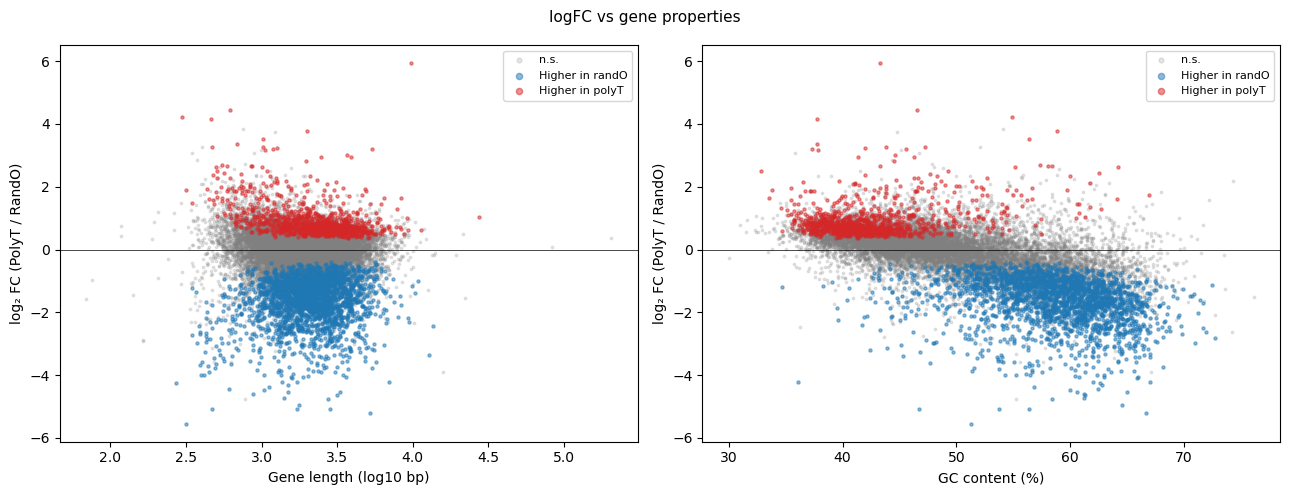

In [61]:
sig = results["FDR"] < 0.05
pos = sig & (results["logFC"] > 0)   # higher in polyT
neg = sig & (results["logFC"] < 0)   # higher in randO

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
specs = [
    ("gene_length", "Gene length (log10 bp)",  True),
    ("gc_content",  "GC content (%)",           False),
]
for ax, (col, xlabel, log_x) in zip(axes, specs):
    x = np.log10(results[col]) if log_x else results[col]
    ax.scatter(x[~sig], results.loc[~sig,  "logFC"], c="grey",    s=3, alpha=0.2, label="n.s.")
    ax.scatter(x[neg],  results.loc[neg,   "logFC"], c="#1f77b4", s=5, alpha=0.5, label="Higher in randO")
    ax.scatter(x[pos],  results.loc[pos,   "logFC"], c="#d62728", s=5, alpha=0.5, label="Higher in polyT")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("log\u2082 FC (PolyT / RandO)")
    ax.legend(fontsize=8, markerscale=2)

plt.suptitle("logFC vs gene properties", fontsize=11)
plt.tight_layout()
plt.show()

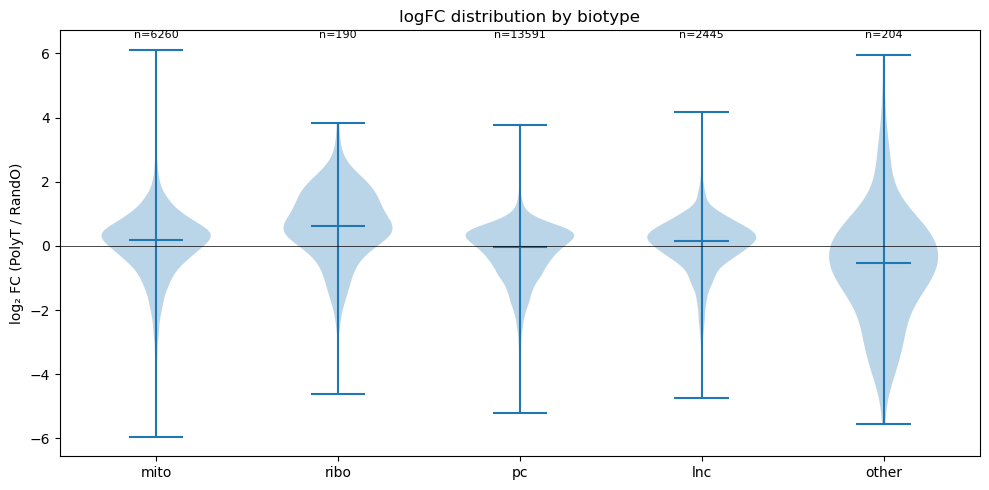

In [62]:
def assign_biotype(row):
    if row.get("is_mito", False): return "mito"
    if row.get("is_ribo", False): return "ribo"
    if row.get("is_pc",   False): return "pc"
    if row.get("is_lnc",  False): return "lnc"
    return "other"

results["biotype"] = results.apply(assign_biotype, axis=1)
order = ["mito", "ribo", "pc", "lnc", "other"]

fig, ax = plt.subplots(figsize=(10, 5))
vdata = [results.loc[results["biotype"] == bio, "logFC"].dropna().values for bio in order]
parts = ax.violinplot(vdata, positions=range(len(order)), showmedians=True, widths=0.6)

y_top = max(results["logFC"].max(), 1) * 1.05
for pos, bio, data in zip(range(len(order)), order, vdata):
    ax.text(pos, y_top, f"n={len(data)}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("log\u2082 FC (PolyT / RandO)")
ax.set_title("logFC distribution by biotype")
plt.tight_layout()
plt.show()

In [63]:
sig_randO   = results.loc[(results["FDR"] < 0.05) & (results["logFC"] < 0), "gene_name"].tolist()
sig_polyT = results.loc[(results["FDR"] < 0.05) & (results["logFC"] > 0), "gene_name"].tolist()

['PLEC', 'SBF1', 'PPP1R9B', 'MYO1G', 'FLNA', 'TSC22D4', 'CORO1A', 'NOTCH1', 'CACTIN', 'PFKL', 'ENSG00000259952.1', 'PPP6R1', 'HFM1', 'SLC12A7', 'MC1R', 'TBC1D3B', 'PCNX3', 'CLCN7', 'SPNS1', 'SCRIB', 'WDR6', 'PRRC2A', 'AKT1', 'ENSG00000276570.1', 'PSD4', 'ENSG00000290069.1', 'ENSG00000230483.1', 'BAG6', 'NFKB2', 'PRKXP1', 'UBA1', 'CORO6', 'ANO9', 'ENSG00000304860.1', 'SUN2', 'ADAMTS7P1', 'ZMIZ2', 'H2BC21', 'CRTC2', 'SETD1B', 'CDC25B', 'PGGHG', 'ENSG00000236772.1', 'KIF21B', 'ENSG00000310430.1', 'PTOV1-AS2', 'BICRA', 'POM121B', 'MED25', 'DBNL', 'MAN2B1', 'ATP13A1', 'HLA-C', 'ENSG00000288873.3', 'PLCG1', 'RHPN1', 'PKD1', 'AKT2', 'AHR', 'TPPP', 'GPR108', 'MEN1', 'SIPA1', 'U2AF2', 'NCSTN', 'SLC4A2', 'TREX2', 'PRKCSH', 'KMT2B', 'NUTM2A', 'ENSG00000281383.1', 'CAPN15', 'ARHGAP33', 'SYVN1', 'ABCD1', 'XAB2', 'TTYH3', 'ALDH16A1', 'ELF4', 'WIZ', 'PRR14', 'PCIF1', 'MAMDC4', 'SKIC2', 'PANK4', 'SLC35F6', 'TRMT2A', 'USP19', 'MED12', 'SH3BP1', 'ENSG00000268858.3', 'CAMTA2', 'CUL9', 'AP1B1', 'ENSG00000

/home/mcaskey/10XvParse/XvP_utils/plotting/cross_comparison.py:200: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(n_per_db, 'nlp'))
/home/mcaskey/10XvParse/XvP_utils/plotting/cross_comparison.py:200: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(n_per_db, 'nlp'))


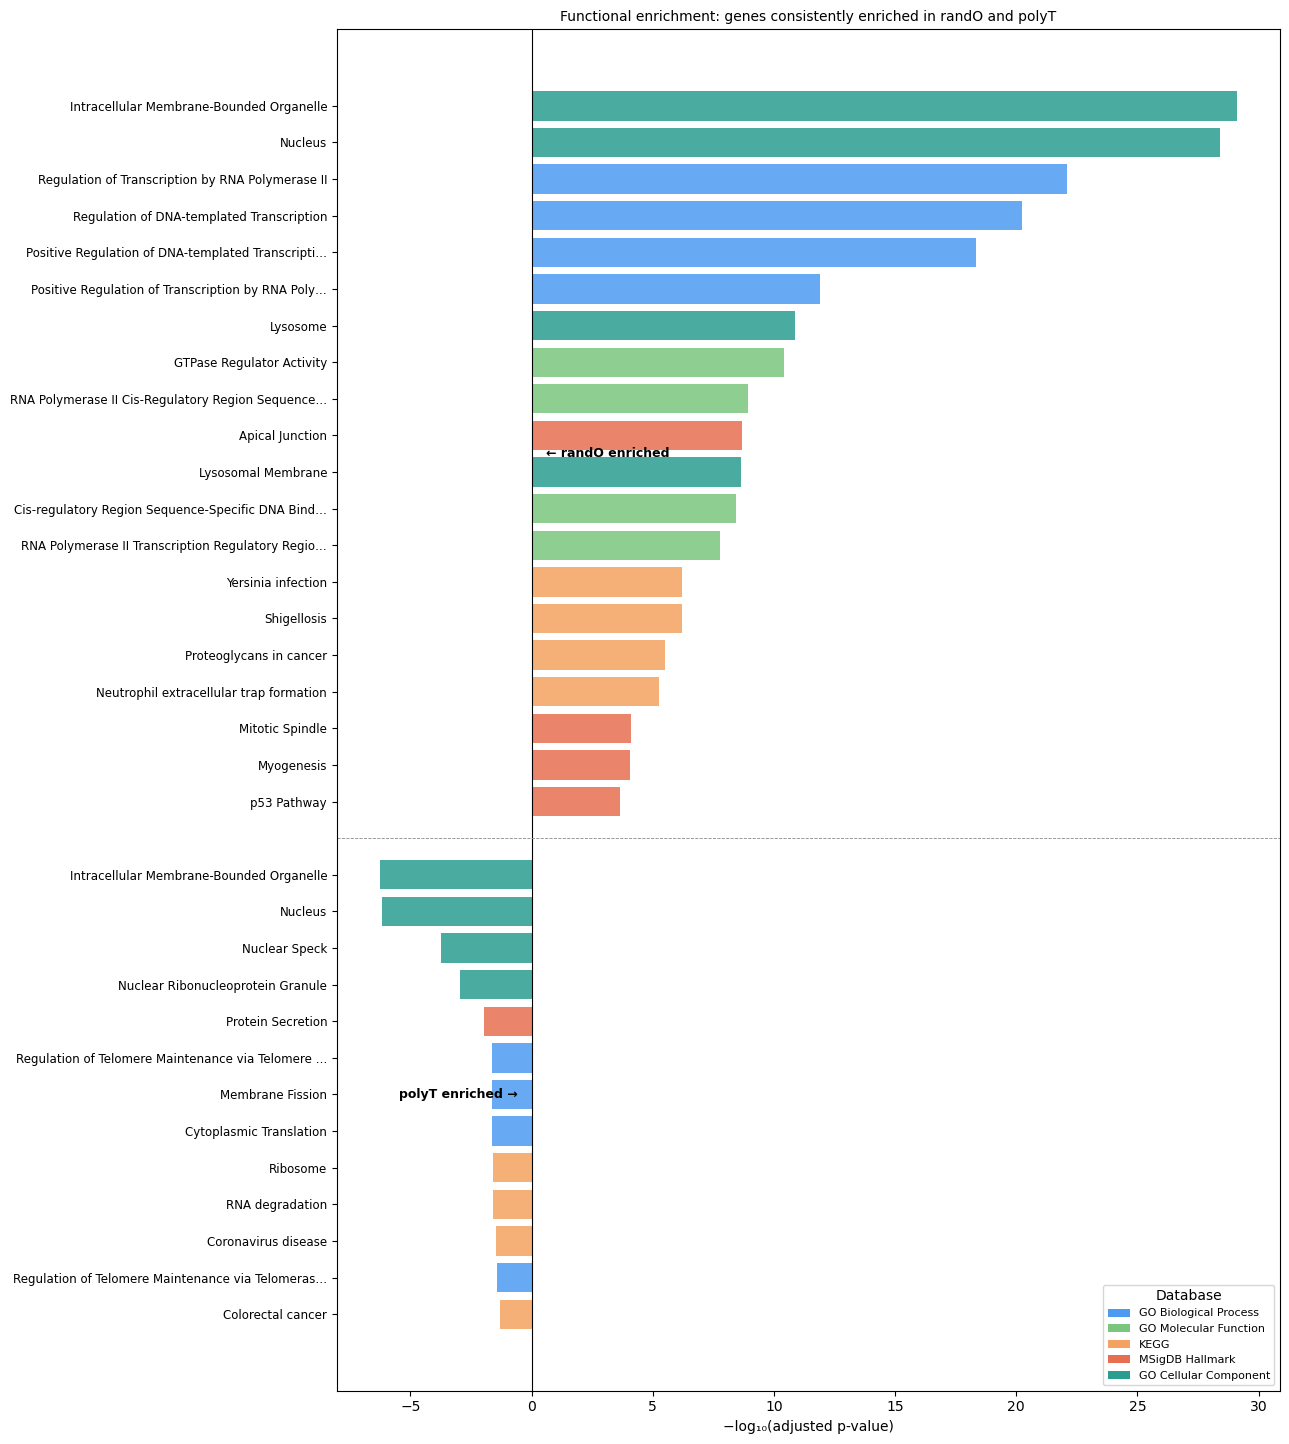

In [64]:
background = combined.index
sig_genes = (sig_randO, sig_polyT)
comparing = ("randO", "polyT")

enrichment_results = []
for gene_list, side in zip(sig_genes, comparing):
    print(gene_list)
    # Get genes consistently enriched
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=['GO_Biological_Process_2026', 'GO_Molecular_Function_2026',
                'KEGG_2021_Human', 'MSigDB_Hallmark_2020', 'GO_Cellular_Component_2026'],
        background=background,   
        outdir=None,
        verbose=False,
    )

    enr_results = enr.results[enr.results['Adjusted P-value'] < 0.05].sort_values('Adjusted P-value')
    enr_results.to_csv(f"{side}_outliers/enrichment_results.csv")
    enrichment_results.append(enr_results)

plotting.plot_term_enrichment_bar(enrichment_results, comparing)

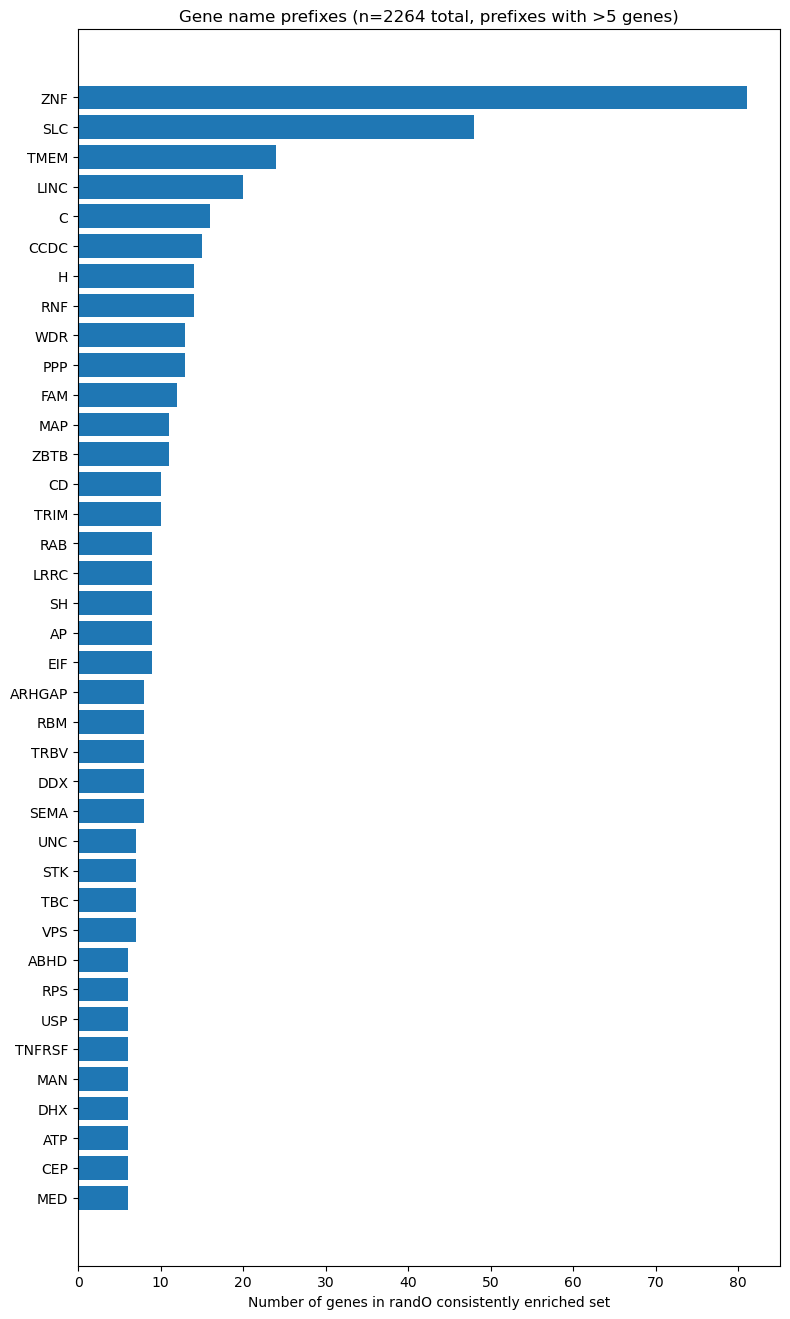

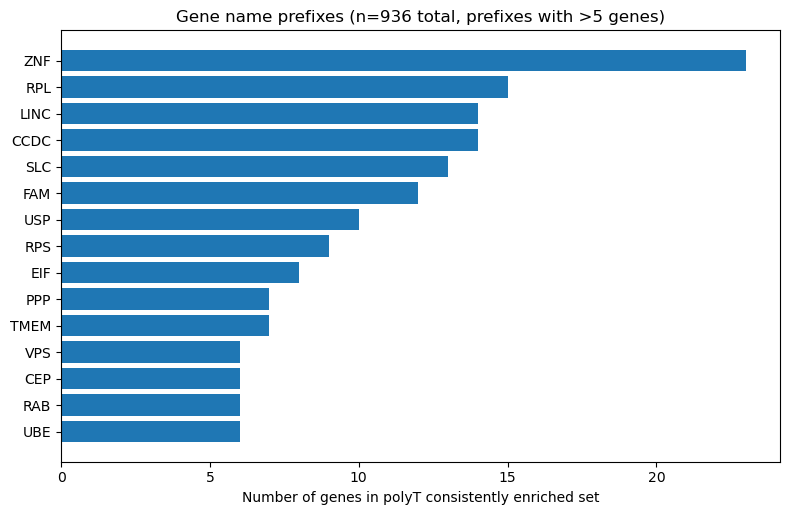

In [65]:
def extract_prefix(gene_name):
        # Leading letters up to first digit or hyphen: RPS27→RPS, MT-CO1→MT, ATP5F1A→ATP
        m = re.match(r'^([A-Z]+)', gene_name)
        return m.group(1) if m else gene_name

prefix_threshold = 5
for gene_list, side in zip(sig_genes, comparing):
    gene_list = [g for g in gene_list if not g.startswith("ENSG")]
    prefixes = pd.Series(gene_list).apply(extract_prefix)
    prefix_counts = prefixes.value_counts()

    with open(f"{side}_outliers/enriched_prefixes.txt", "w") as f:
        for prefix in sorted(prefix_counts.index.tolist()):
            f.write(f"{prefix}\n")

    prefix_counts_filtered = prefix_counts[prefix_counts > prefix_threshold].sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, max(4, len(prefix_counts_filtered) * 0.35)))
    ax.barh(prefix_counts_filtered.index[::-1], prefix_counts_filtered.values[::-1])
    ax.set_xlabel(f"Number of genes in {side} consistently enriched set")
    ax.set_title(f"Gene name prefixes (n={len(gene_list)} total, prefixes with >{prefix_threshold} genes)")
    plt.tight_layout()
    plt.show()
    plt.close(fig)